<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/Lab8_ML(Neural_Network).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 (Activation Function)

Libraries Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as train_test_split

Sigmoid Function

In [13]:
def Sigmoid(z):
  return 1/(1+np.exp(-z))

In [19]:
def dSigmoid(z):
  s = 1/(1+np.exp(-z))
  return s * (1-s)

ReLU Function

In [4]:
def ReLU(z):
  return np.maximum(0,z)

dReLU Function

In [5]:
def dRelu(z):
 return np.where(z<0,0,1)


Testing Functions

In [6]:
z=np.array([-3,-2,-1,1,2,3])
print("Sigmoid(z) = ",Sigmoid(z))
print("ReLU(z) = ",ReLU(z))
print("dReLU(z) = ",dRelu(z))

Sigmoid(z) =  [21.08553692  8.3890561   3.71828183  1.36787944  1.13533528  1.04978707]
ReLU(z) =  [0 0 0 1 2 3]
dReLU(z) =  [0 0 0 1 1 1]


Task 2 (Matrix Initialization)

In [7]:
df=pd.read_csv('/content/support2.csv')
df.head()

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,11.0,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [8]:
data=df[['age','death','sex','dzgroup']]

In [ ]:
data.head()

,age,death,sex,dzgroup
1,62.84998,0,male,Lung Cancer
2,60.33899,1,female,Cirrhosis
3,52.74698,1,female,Cirrhosis
4,42.38498,1,female,Lung Cancer
5,79.88495,0,female,ARF/MOSF w/Sepsis


In [11]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
X = df.iloc[:, 0:3].values.T
Y = df.iloc[:, 3].values.reshape(1, -1)

m = X.shape[1]
split = int(0.8 * m)
Xtrain = X[:, :split]
Xtest = X[:, split:]

Ytrain = Y[:, :split]
Ytest = Y[:, split:]

n = Xtrain.shape[0]
mtrain = Xtrain.shape[1]
mtest = Xtest.shape[1]

h1 = 5
h2 = 4
out = 1

Z1 = np.zeros((h1, mtrain))
A1 = np.zeros((h1, mtrain))

Z2 = np.zeros((h2, mtrain))
A2 = np.zeros((h2, mtrain))

Z3 = np.zeros((out, mtrain))
A3 = np.zeros((out, mtrain))

dZ1 = np.zeros((h1, mtrain))
dZ2 = np.zeros((h2, mtrain))
dZ3 = np.zeros((out, mtrain))

dZ1cache = np.zeros((h1, mtrain))
dZ2cache = np.zeros((h2, mtrain))
dZ3cache = np.zeros((out, mtrain))

np.random.seed(42)

W1 = np.random.randn(h1, n) * 0.01
B1 = np.random.randn(h1, 1) * 0.01

W2 = np.random.randn(h2, h1) * 0.01
B2 = np.random.randn(h2, 1) * 0.01

W3 = np.random.randn(out, h2) * 0.01
B3 = np.random.randn(out, 1) * 0.01

dW1 = np.zeros_like(W1)
dB1 = np.zeros_like(B1)

dW2 = np.zeros_like(W2)
dB2 = np.zeros_like(B2)

dW3 = np.zeros_like(W3)
dB3 = np.zeros_like(B3)

Task 3 (Initializing Weights)

In [14]:
def forward(Xdata):
    global Z1, A1, Z2, A2, Z3, A3

    Z1 = np.dot(W1, Xdata) + B1
    A1 = ReLU(Z1)

    Z2 = np.dot(W2, A1) + B2
    A2 = ReLU(Z2)

    Z3 = np.dot(W3, A2) + B3
    A3 = Sigmoid(Z3)

    return A3

def cost_function(Ytrue, Ypred):
    m = Ytrue.shape[1]
    cost = -(1/m) * np.sum(Ytrue*np.log(Ypred+1e-8) + (1-Ytrue)*np.log(1-Ypred+1e-8))
    return cost

A3train = forward(Xtrain)
train_cost = cost_function(Ytrain, A3train)

A3test = forward(Xtest)
test_cost = cost_function(Ytest, A3test)

print("Training Cost:", train_cost)
print("Testing Cost:", test_cost)


Training Cost: 0.6938689598912134
Testing Cost: 0.6942472783049203


In [20]:
def backward(Xdata, Ytrue, A3pred):
    global dZ3, dW3, dB3, dZ2, dW2, dB2, dZ1, dW1, dB1

    m = Xdata.shape[1]

    # Output Layer (dZ3, dW3, dB3)
    dZ3 = A3pred - Ytrue
    dW3 = (1/m) * np.dot(dZ3, A2.T)
    dB3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)

    # Hidden Layer 2 (dZ2, dW2, dB2)
    dZ2 = np.dot(W3.T, dZ3) * dRelu(Z2) # Element-wise multiplication with derivative of ReLU
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    dB2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden Layer 1 (dZ1, dW1, dB1)
    dZ1 = np.dot(W2.T, dZ2) * dRelu(Z1) # Element-wise multiplication with derivative of ReLU
    dW1 = (1/m) * np.dot(dZ1, Xdata.T)
    dB1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

### Backward Pass Demonstration and Verification

## Training the Neural Network (Gradient Descent)

In [23]:
def update_parameters(learning_rate):
    global W1, B1, W2, B2, W3, B3

    W1 = W1 - learning_rate * dW1
    B1 = B1 - learning_rate * dB1
    W2 = W2 - learning_rate * dW2
    B2 = B2 - learning_rate * dB2
    W3 = W3 - learning_rate * dW3
    B3 = B3 - learning_rate * dB3


In [24]:
epochs = 1000
learning_rate = 0.01

train_costs = []
test_costs = []

for i in range(epochs):
    # Forward Pass on Training Data
    A3train_pred = forward(Xtrain)
    cost_train = cost_function(Ytrain, A3train_pred)
    train_costs.append(cost_train)

    # Backward Pass on Training Data
    backward(Xtrain, Ytrain, A3train_pred)

    # Update Parameters
    update_parameters(learning_rate)

    # Forward Pass on Test Data (for evaluation, not training)
    A3test_pred = forward(Xtest)
    cost_test = cost_function(Ytest, A3test_pred)
    test_costs.append(cost_test)

    if i % 100 == 0:
        print(f"Epoch {i}: Train Cost = {cost_train:.6f}, Test Cost = {cost_test:.6f}")

print("\nTraining complete.")

Epoch 0: Train Cost = 0.693869, Test Cost = 0.693518
Epoch 100: Train Cost = 0.656131, Test Cost = 0.633773
Epoch 200: Train Cost = 0.633142, Test Cost = 0.593555
Epoch 300: Train Cost = 0.619003, Test Cost = 0.565855
Epoch 400: Train Cost = 0.610202, Test Cost = 0.546303
Epoch 500: Train Cost = 0.604664, Test Cost = 0.532171
Epoch 600: Train Cost = 0.601147, Test Cost = 0.521729
Epoch 700: Train Cost = 0.598901, Test Cost = 0.513864
Epoch 800: Train Cost = 0.597470, Test Cost = 0.507854
Epoch 900: Train Cost = 0.596564, Test Cost = 0.503224

Training complete.


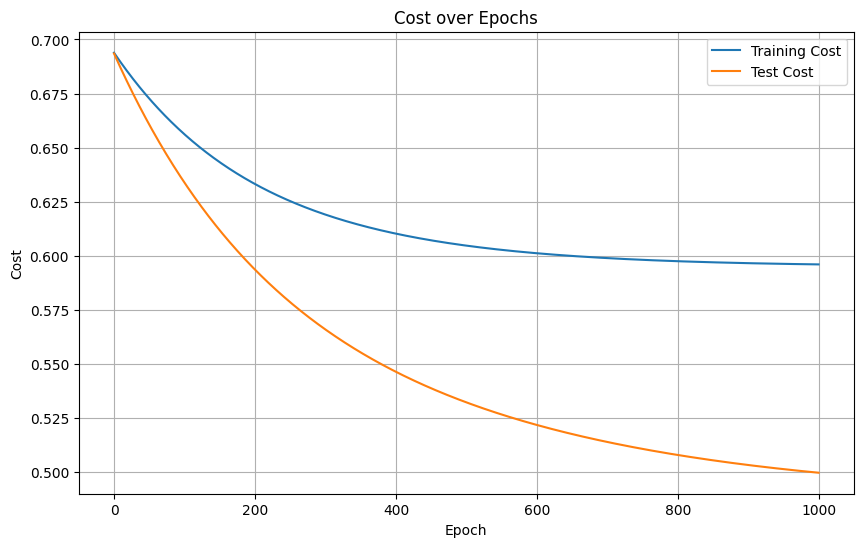

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_costs, label='Training Cost')
plt.plot(test_costs, label='Test Cost')
plt.title('Cost over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()


### Lab : Final Conclusion

This lab provided a practical introduction to building a simple neural network from scratch. We successfully implemented and demonstrated the core components of a neural network:

1.  **Activation Functions**: Defined and understood the role of `Sigmoid` and `ReLU` functions, along with their derivatives, in introducing non-linearity.
2.  **Network Architecture and Initialization**: Set up a 3-layer neural network and initialized its weights and biases.
3.  **Data Preprocessing**: Handled categorical data to prepare it for network input.
4.  **Forward Propagation**: Implemented the `forward` function to compute predictions and visualised the activations across layers for a sample input.
5.  **Cost Function**: Utilized the binary cross-entropy to quantify prediction errors.
6.  **Backward Propagation**: Implemented the `backward` function to calculate gradients of the cost with respect to weights and biases, which are essential for learning.
7.  **Training Loop**: Integrated forward and backward passes with a `gradient descent` optimizer to iteratively update network parameters, reducing the cost over epochs.

Through this process, we observed how the neural network learns from data by minimizing the cost function, demonstrating a foundational understanding of how neural networks operate. The plots of training and test costs over epochs provided visual evidence of the learning process.

In [22]:
# Perform a forward pass for the training data to get A3train and other intermediate values
# This is necessary because the backward function uses A1, A2, Z1, Z2 from the last forward pass
A3train_current = forward(Xtrain)

# Call the backward function with training data
backward(Xtrain, Ytrain, A3train_current)

# Display some of the calculated gradients to verify
print(f"""--- Backward Pass Results (Gradients) ---
dW1 (Gradient of W1):
{dW1[:, :5]}
dB1 (Gradient of B1):
{dB1}
dW2 (Gradient of W2):
{dW2[:, :5]}
dB2 (Gradient of B2):
{dB2}
dW3 (Gradient of W3):
{dW3}
dB3 (Gradient of B3):
{dB3}
""")

--- Backward Pass Results (Gradients) ---
dW1 (Gradient of W1):
[[-2.48932111e-03 -1.19774696e-05 -2.30734431e-05]
 [-6.84186806e-04 -3.29199260e-06 -6.34170709e-06]
 [-1.23324502e-04 -5.93380848e-07 -1.14309112e-06]
 [ 3.41654054e-03  1.64388235e-05  3.16678123e-05]
 [ 5.61342664e-04  2.71149192e-06  5.21263766e-06]]
dB1 (Gradient of B1):
[[-4.13306756e-05]
 [-1.13596847e-05]
 [-2.04758034e-06]
 [ 5.67254776e-05]
 [ 9.32800434e-06]]
dW2 (Gradient of W2):
[[-0.00095959 -0.002927   -0.00308446 -0.00101455 -0.00037648]
 [ 0.          0.          0.          0.          0.        ]
 [-0.00029896 -0.00091192 -0.00096098 -0.00031609 -0.00011729]
 [ 0.          0.          0.          0.          0.        ]]
dB2 (Gradient of B2):
[[-0.00323354]
 [ 0.        ]
 [-0.00100742]
 [ 0.        ]]
dW3 (Gradient of W3):
[[0.00114391 0.         0.00247897 0.        ]]
dB3 (Gradient of B3):
[[0.21870113]]



## Task 5: Forward Pass Demonstration and Visualization

In [15]:
# Take a small sample from the test data for demonstration
sample_index = 0 # You can change this to see different examples
X_sample = Xtest[:, sample_index:sample_index+1]

print(f"Input for sample {sample_index}:\n{X_sample}\n")

# Perform a forward pass for the sample
_ = forward(X_sample)

# Display the intermediate and final activations (using global variables set by forward)
print(f"--- Forward Pass Results for Sample {sample_index} ---")
print(f"Activation of Hidden Layer 1 (A1):\n{A1}\n")
print(f"Activation of Hidden Layer 2 (A2):\n{A2}\n")
print(f"Final Output (A3 - Predicted Probability):\n{A3}\n")

# Compare with the true label (for context)
print(f"True Label for Sample {sample_index}: {Ytest[0, sample_index]}")

Input for sample 0:
[[91.64398]
 [ 1.     ]
 [ 0.     ]]

--- Forward Pass Results for Sample 0 ---
Activation of Hidden Layer 1 (A1):
[[0.4482031 ]
 [1.38329533]
 [1.4580703 ]
 [0.4835092 ]
 [0.18848802]]

Activation of Hidden Layer 2 (A2):
[[0.00390032]
 [0.        ]
 [0.0180086 ]
 [0.        ]]

Final Output (A3 - Predicted Probability):
[[0.50082389]]

True Label for Sample 0: 0


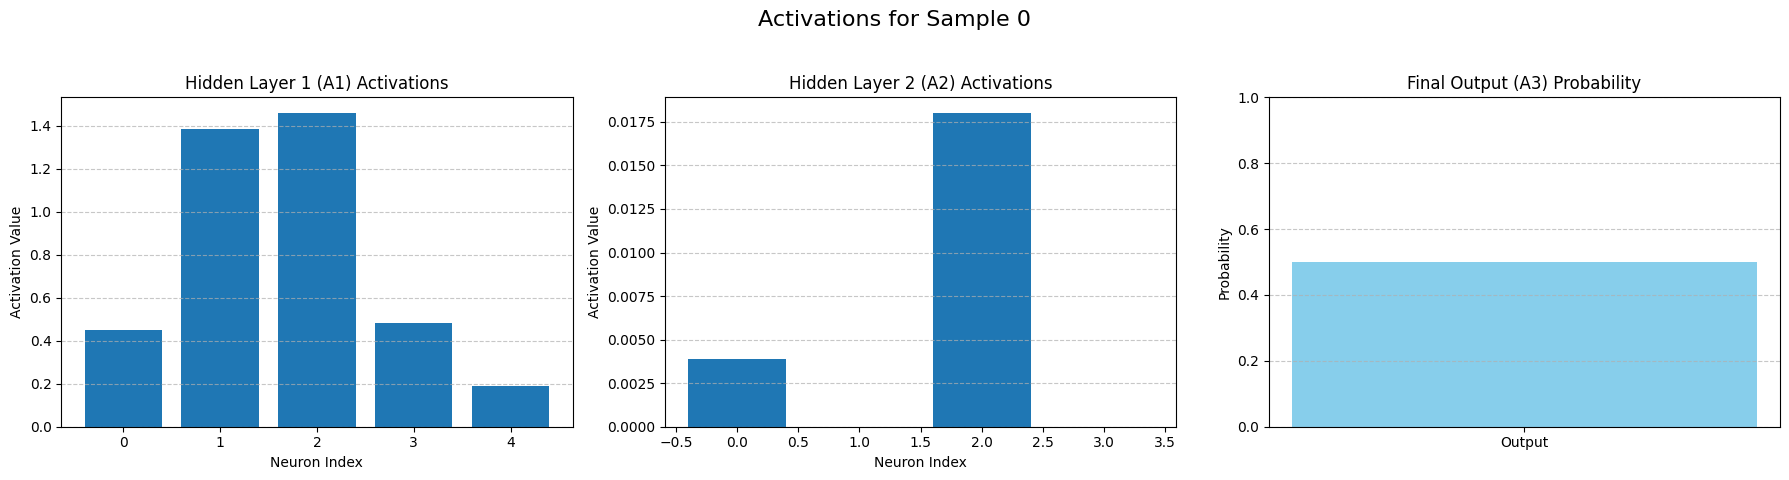

In [18]:
import matplotlib.pyplot as plt

# --- Visualizing Activations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Activations for Sample {sample_index}', fontsize=16)

# Plot A1 (Hidden Layer 1 Activations)
axes[0].bar(range(A1.shape[0]), A1.flatten())
axes[0].set_title('Hidden Layer 1 (A1) Activations')
axes[0].set_xlabel('Neuron Index')
axes[0].set_ylabel('Activation Value')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot A2 (Hidden Layer 2 Activations)
axes[1].bar(range(A2.shape[0]), A2.flatten())
axes[1].set_title('Hidden Layer 2 (A2) Activations')
axes[1].set_xlabel('Neuron Index')
axes[1].set_ylabel('Activation Value')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot A3 (Final Output Probability)
axes[2].bar(['Output'], A3.flatten(), color='skyblue')
axes[2].set_title('Final Output (A3) Probability')
axes[2].set_ylim(0, 1) # Probability should be between 0 and 1
axes[2].set_ylabel('Probability')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()